In [1]:
%cd ../..

/home/eli/AnacondaProjects/epych


In [2]:
%env DASK_LOGGING__DISTRIBUTED=CRITICAL
%env SPYTMPDIR=/mnt/data/tmp_storage
%env SPYLOGLEVEL=CRITICAL
%env SPYPARLOGLEVEL=CRITICAL

env: DASK_LOGGING__DISTRIBUTED=CRITICAL
env: SPYTMPDIR=/mnt/data/tmp_storage
env: SPYLOGLEVEL=CRITICAL
env: SPYPARLOGLEVEL=CRITICAL


In [3]:
import collections
import functools
import logging
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
import pandas as pd
import quantities as pq

import epych
from epych.statistics import alignment, spectrum

[striatum:1280752] shmem: mmap: an error occurred while determining whether or not /tmp/ompi.striatum.1000/jf.0/3509256192/shared_mem_cuda_pool.striatum could be created.
[striatum:1280752] create_and_attach: unable to create shared memory BTL coordinating structure :: size 134217728 


In [4]:
%matplotlib inline
# %load_ext autoreload
# %autoreload 2

In [5]:
logging.basicConfig(level=logging.INFO)

In [6]:
ADAPTED_ONSET = pq.Quantity(-1.0) * pq.second
ADAPTED_OFFSET = pq.Quantity(-0.5) * pq.second
ODDBALL_ONSET = pq.Quantity(-1.9017372477960602e-14) * pq.second
ODDBALL_OFFSET = pq.Quantity(0.5004545430388676) * pq.second
OFFSET = pq.Quantity(0.010) * pq.second
EVENTS = {
    "Oddball": (ODDBALL_ONSET.magnitude, 'lightgreen'),
    "Offset": (ODDBALL_OFFSET.magnitude, 'red'),
}
FREQ_RANGE = (spectrum.THETA_BAND[0], spectrum.GAMMA_BAND[1])
FORCE_RECOMPUTE = False

In [7]:
CONDITIONS = ["lonaive", "go_gloexp", "go_seqctl", "lo_gloexp", "lo_rndctl", "igo_seqctl"]
LAMINAE = {
    'L2/3': lambda loc: "2/3" in loc,
    'L4': lambda loc: "4" in loc,
    'L5/6': lambda loc: "5" in loc or "6" in loc,
    'L1/6': lambda loc: "1" in loc or "6" in loc,
}

In [8]:
BANDS = {
    "Theta": spectrum.THETA_BAND,
    "Alpha/Beta": spectrum.ALPHA_BETA_BAND,
    "Gamma": spectrum.LOW_GAMMA_BAND,
}
BAND_NAMES = {
    "Theta": "theta",
    "Alpha/Beta": "alphabeta",
    "Gamma": "gamma"
}
BAND_LATEX = {
    "Theta": "$\\theta$",
    "Alpha/Beta": "$\\alpha/\\beta$",
    "Gamma": "$\\gamma$"
}

In [9]:
AREA_TITLES = {
    "VISal": "AL",
    "VISam": "AM",
    "VISl": "LM",
    "VISp": "V1",
    "VISpm": "PM",
    "VISrl": "RL",
}
def stattitle(name, stat, layer=None):
    suffix = " (%s)" % layer if layer else ""
    if name in AREA_TITLES:
        return "Sub-" + AREA_TITLES[name] + suffix
    return name + suffix
anatomical_areas = ['VISp', 'VISl', 'VISrl', 'VISal', 'VISpm', 'VISam']

In [10]:
def initialize_spectrum(key, signal, path=None):
    area = os.path.commonprefix([loc for loc in signal.channels.location])
    return epych.statistics.spectrum.Spectrogram(signal.df, signal.channels, signal.f0, taper="hann", path=path + "/" + key, time_window=0.200)

In [11]:
def baselined_oscillatory(spectrogram):
    return spectrogram.oscillatory().baseline(-0.250 * pq.second, -0.050 * pq.second, decibels=True)

def oscillatory_oddball(spectrogram):
    return spectrogram[(ODDBALL_ONSET - OFFSET).magnitude:(ODDBALL_OFFSET + OFFSET).magnitude].oscillatory()

In [12]:
spectrograms = {}

In [13]:
for cond in CONDITIONS:
    cond_path = "/mnt/data/000253/grand_hippocampal_spectrogram_downsample4_%s" % cond
    raw_spectrograms = epych.statistic.Summary.unpickle(cond_path, epych.statistics.spectrum.Spectrogram).results()
    spectrograms[cond] = raw_spectrograms.smap(oscillatory_oddball)
    del raw_spectrograms
    logging.info("Loaded LFP spectrograms across condition %s" % cond)

INFO:root:Loaded LFP spectrograms across condition lonaive
INFO:root:Loaded LFP spectrograms across condition go_gloexp
INFO:root:Loaded LFP spectrograms across condition go_seqctl
INFO:root:Loaded LFP spectrograms across condition lo_gloexp
INFO:root:Loaded LFP spectrograms across condition lo_rndctl
INFO:root:Loaded LFP spectrograms across condition igo_seqctl


In [14]:
PVALUE = 1e-2

In [15]:
CONTRASTS = [("dd", "lo_rndctl", "lonaive"), ("go_contrast", "go_gloexp", "go_seqctl"), ("ssa", "lo_gloexp", "igo_seqctl")]

In [16]:
CONTRAST_TITLES = {
    "go_contrast": "Global Oddball",
    "ssa": "Stimulus Specific Adaptation",
    "dd": "Deviance Detection"
}
CONTRAST_ABBREVS = {"go_contrast": "GO", "ssa": "SSA", "dd": "DD"}
def contrast_stattitle(contrast, name, stat, layer=None):
    suffix = " (%s, %s)" % (CONTRAST_TITLES[contrast], layer) if layer else " (%s)" % CONTRAST_TITLES[contrast]
    return stattitle(name, stat) + suffix

In [17]:
def initialize_grand_cluster_test(key, signals):
    return epych.statistics.grand.GrandNonparametricClusterTest(signals[0].num_channels, len(signals[0].times), alpha=PVALUE, partitions=1000)

In [18]:
contrasts = {}
diffs = {}

In [19]:
def area_name(probe, signals):
    return probe

In [20]:
for (name, condl, condr) in CONTRASTS:
    contrast = epych.statistic.Summary(area_name, initialize_grand_cluster_test)
    contrast._trials = spectrograms[condl]._trials
    contrast_signals = {}
    for k in anatomical_areas:
        contrast_signals[k] = (spectrograms[condl].signals[k].decibels(), spectrograms[condr].signals[k].decibels())
    contrast.calculate([contrast_signals])

    if os.path.exists("/mnt/data/000253/oscillatory_hippocampal_contrasts_" + name + '_01') and not FORCE_RECOMPUTE:
        diffs[name] = epych.recording.EvokedSampling.unpickle("/mnt/data/000253/oscillatory_hippocampal_diffs_" + name + '_01')
        contrasts[name] = epych.recording.EvokedSampling.unpickle("/mnt/data/000253/oscillatory_hippocampal_contrasts_" + name + '_01')
    else:
        hippocampal_contrasts = contrast.results()
        diffs[name] = epych.recording.EvokedSampling(epych.recording.empty_intervals(), epych.recording.empty_trials(), epych.recording.default_units(), **{
            k: v['signal'] for k, v in hippocampal_contrasts.items()
        })
        diffs[name].pickle("/mnt/data/000253/oscillatory_hippocampal_diffs_" + name + '_01')
    
        contrasts[name] = diffs[name].smap(lambda k, sig: sig.fmap(lambda data: data * hippocampal_contrasts[k]['mask']), keys=True)
        contrasts[name].pickle("/mnt/data/000253/oscillatory_hippocampal_contrasts_" + name + '_01')

    logging.info("Nonparametrically contrasted spectrograms for %s" % name)

INFO:root:Nonparametrically contrasted spectrograms for dd
INFO:root:Nonparametrically contrasted spectrograms for go_contrast
/home/eli/miniforge3/envs/ephys/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
INFO:root:Nonparametrically contrasted spectrograms for ssa


In [21]:
CONTRAST_VMAXES = {
    "dd": {
        "All": 2.,
        "Theta": 2.5,
        "Alpha/Beta": 2.5,
        "Gamma": 2.5,
    },
    "go_contrast": {
        "All": 0.6,
        "Theta": 1.5,
        "Alpha/Beta": 1.5,
        "Gamma": 1.5,
    },
    "ssa": {
        "All": 2.,
        "Theta": 2.5,
        "Alpha/Beta": 2.5,
        "Gamma": 2.5,
    },
}

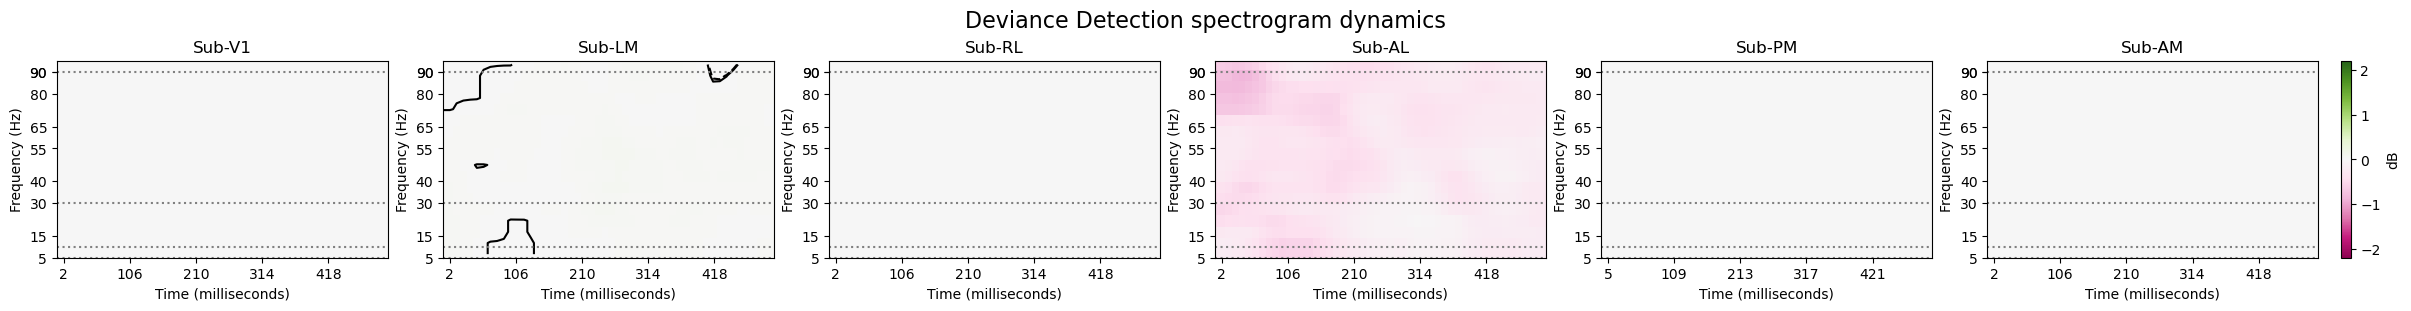

INFO:root:dd in area VISp had 8 channels


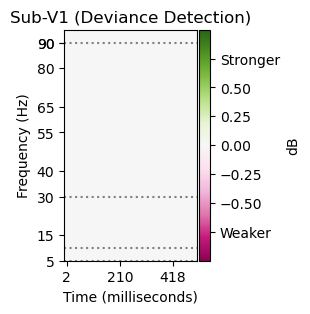

INFO:root:dd in area VISl had 36 channels


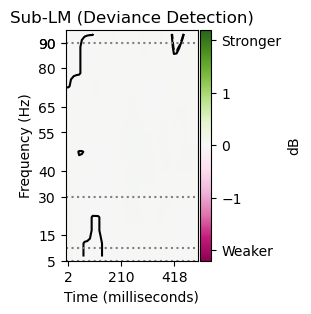

INFO:root:dd in area VISrl had 27 channels


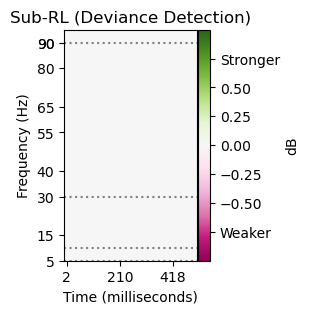

INFO:root:dd in area VISal had 34 channels


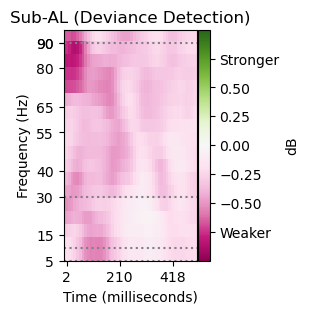

INFO:root:dd in area VISpm had 10 channels


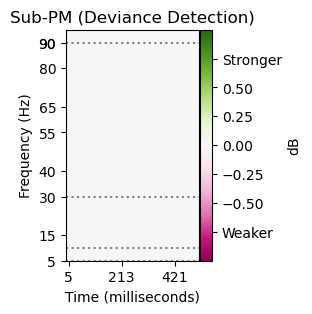

INFO:root:dd in area VISam had 23 channels


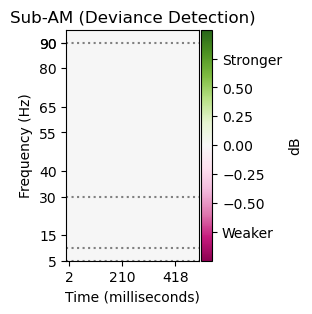

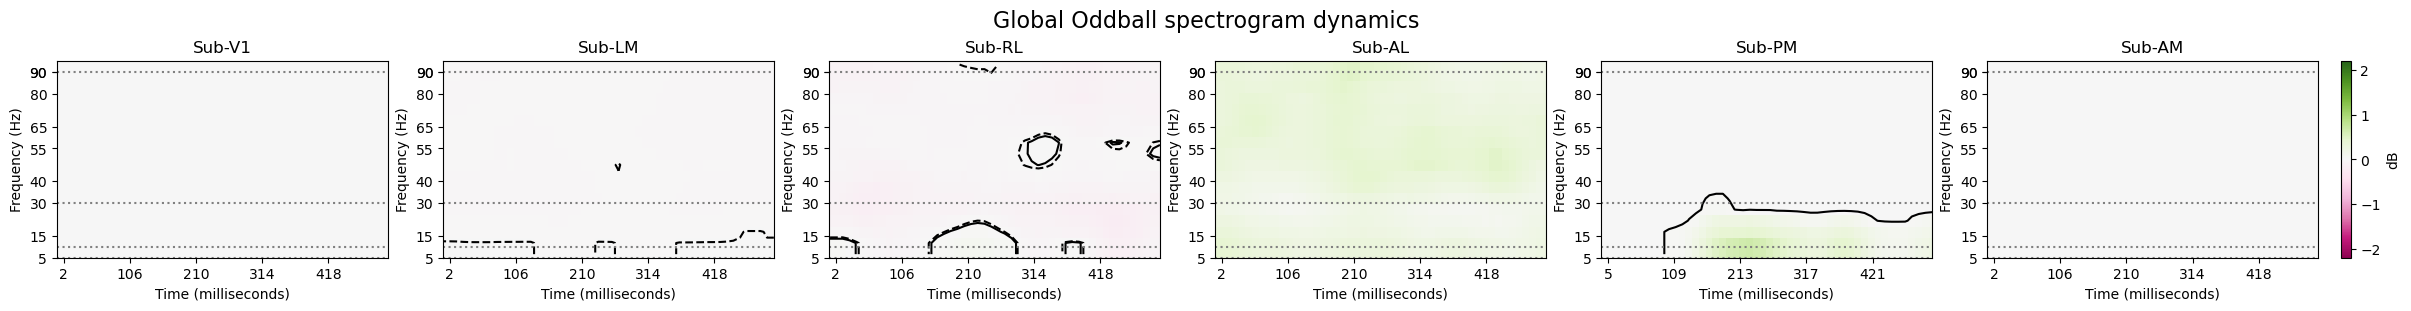

INFO:root:go_contrast in area VISp had 8 channels


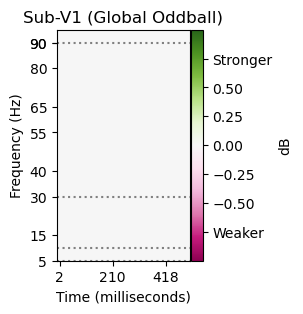

INFO:root:go_contrast in area VISl had 36 channels


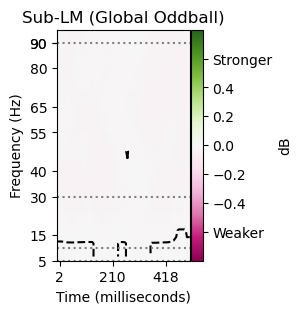

INFO:root:go_contrast in area VISrl had 27 channels


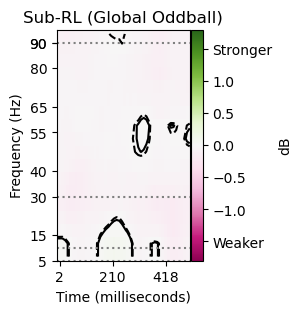

INFO:root:go_contrast in area VISal had 34 channels


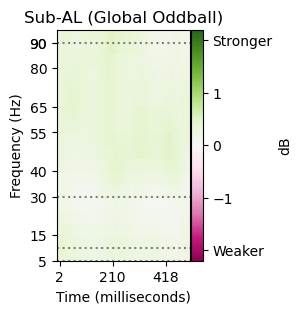

INFO:root:go_contrast in area VISpm had 10 channels


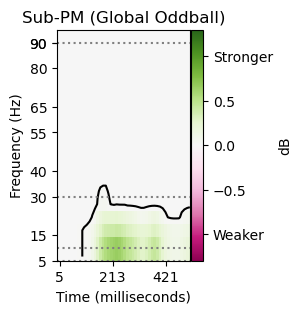

INFO:root:go_contrast in area VISam had 23 channels


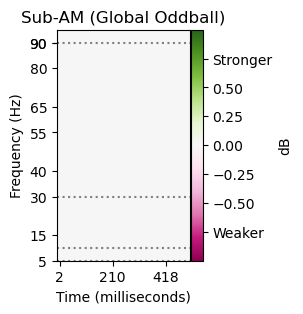

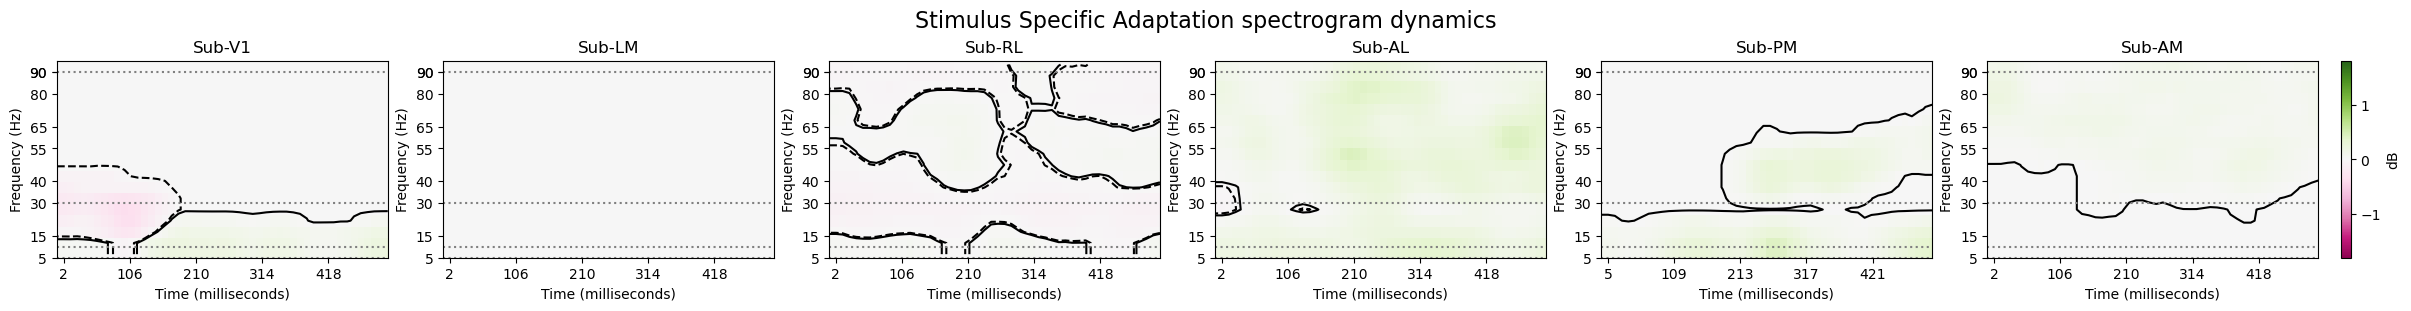

INFO:root:ssa in area VISp had 8 channels


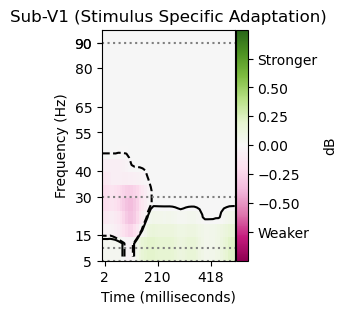

INFO:root:ssa in area VISl had 36 channels


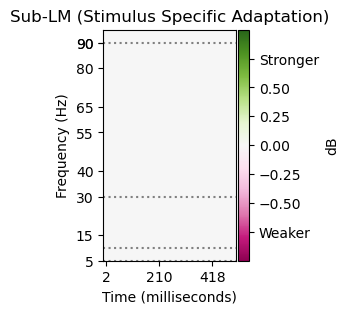

INFO:root:ssa in area VISrl had 27 channels


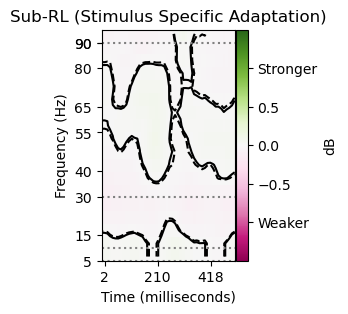

INFO:root:ssa in area VISal had 34 channels


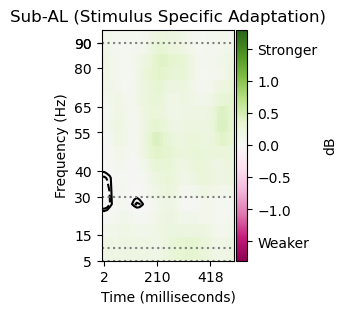

INFO:root:ssa in area VISpm had 10 channels


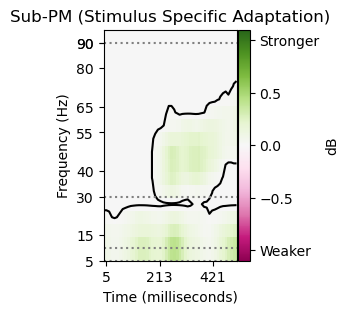

INFO:root:ssa in area VISam had 23 channels


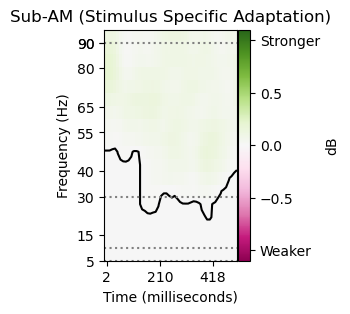

In [26]:
for (name, _, _) in CONTRASTS:
    contrast_title = functools.partial(contrast_stattitle, name)
    contrast = contrasts[name].erp().smap(lambda sig: sig.select_freqs(*FREQ_RANGE))
    contrast.plot(signals=anatomical_areas, sigtitle=functools.partial(stattitle, layer=None), cmap='PiYG', # vmax=CONTRAST_VMAXES[name]["All"], vmin=-CONTRAST_VMAXES[name]["All"],
                  title=CONTRAST_TITLES[name] + " spectrogram dynamics", figure="oscillatory_hippocampal_contrasts_%s_01.svg" % name, contours=True)
    
    for area in anatomical_areas:
        os.makedirs("oscillatory_hippocampal_contrasts_%s_01/" % name, exist_ok=True)
        logging.info("%s in area %s had %d channels" % (name, area, len(contrast.signals[area].channels)))

        contrast.signals[area].plot(title=contrast_title(area, contrasts[name].signals[area], layer=None), cmap='PiYG', # vmax=CONTRAST_VMAXES[name]["All"], vmin=-CONTRAST_VMAXES[name]["All"],
                                    filename="oscillatory_hippocampal_contrasts_%s_01/%s_oddball.svg" % (name, area), cbar_ends=("Stronger", "Weaker"), contours=True)

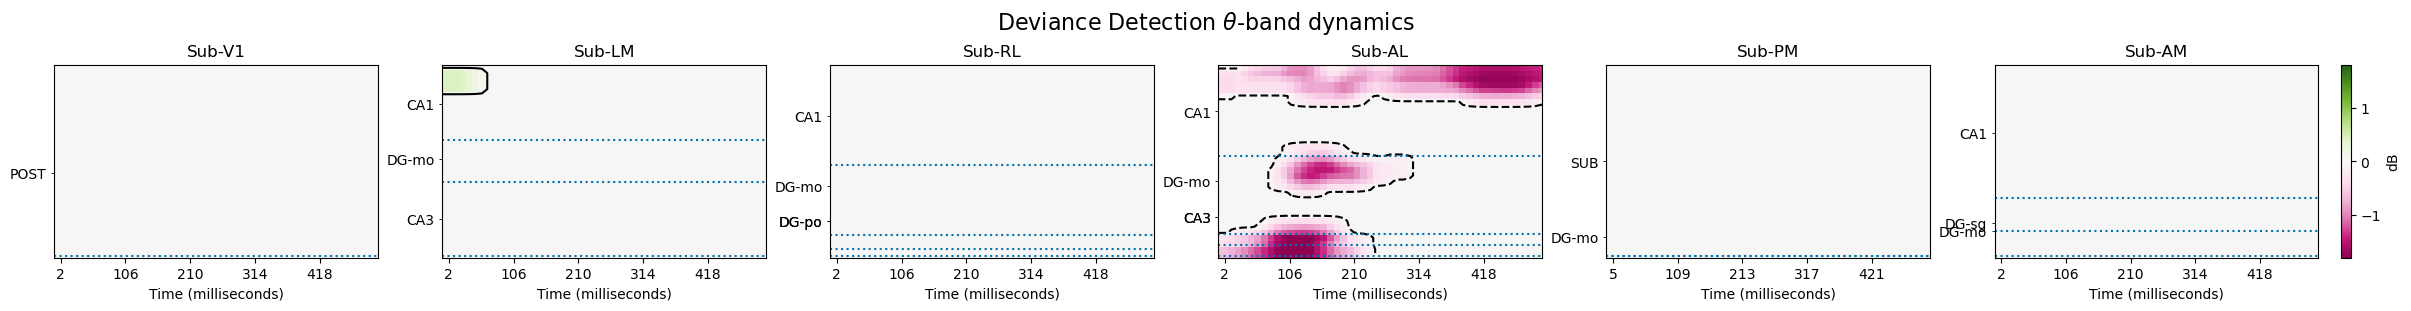

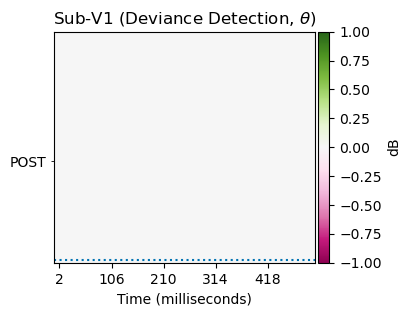

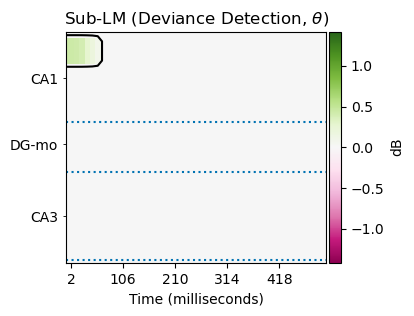

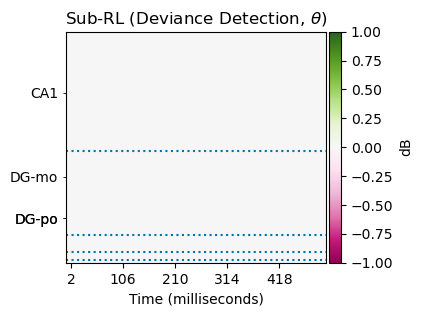

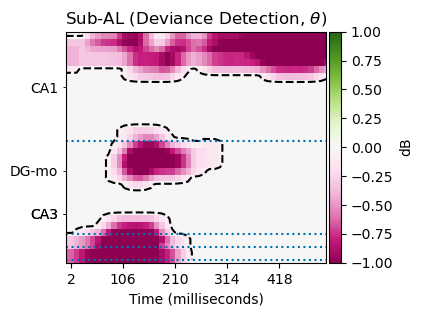

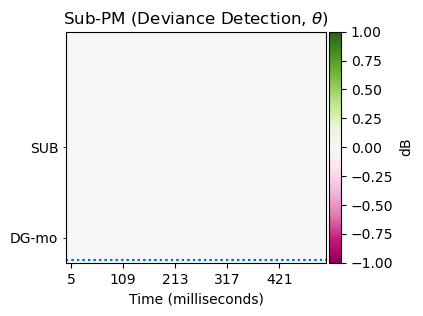

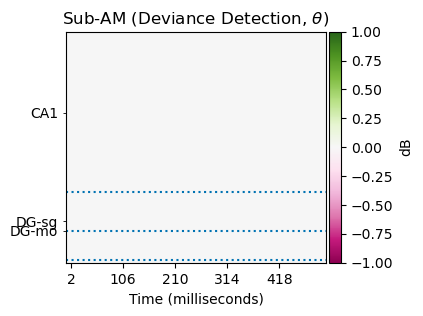

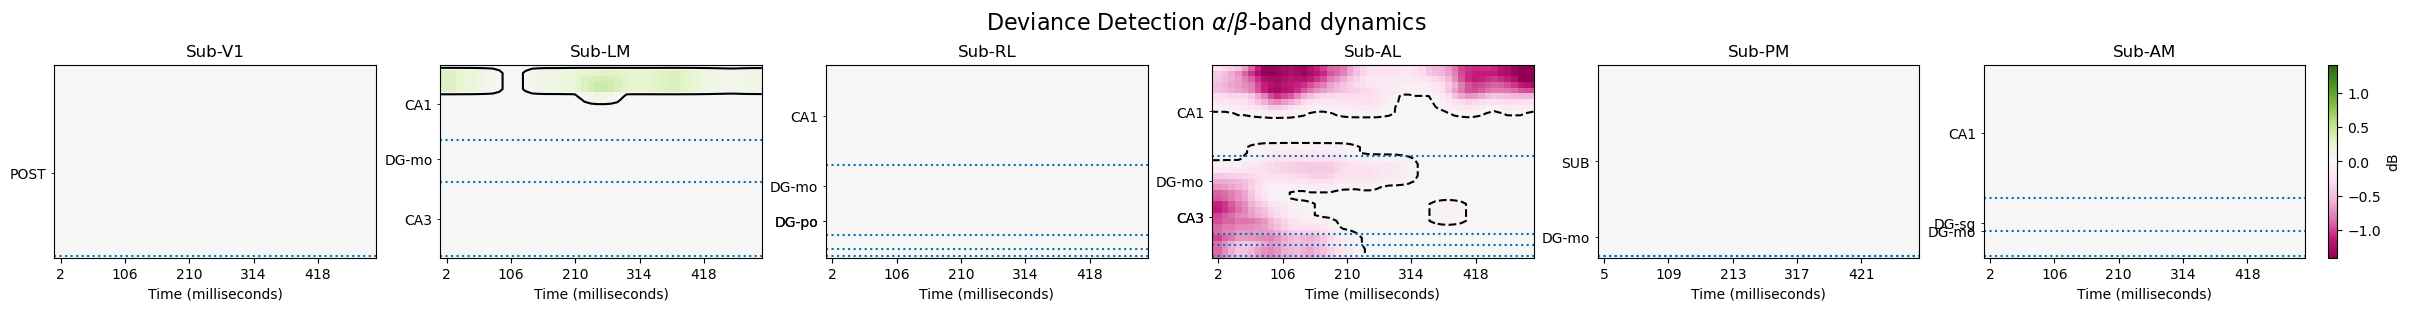

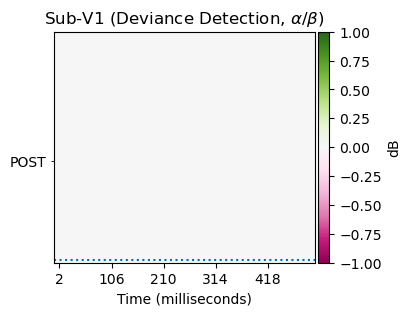

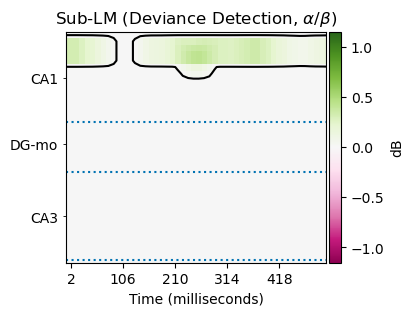

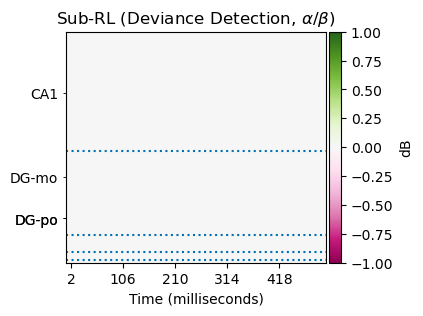

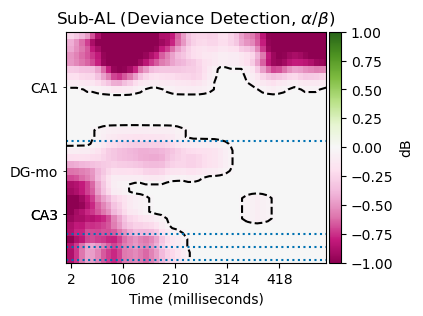

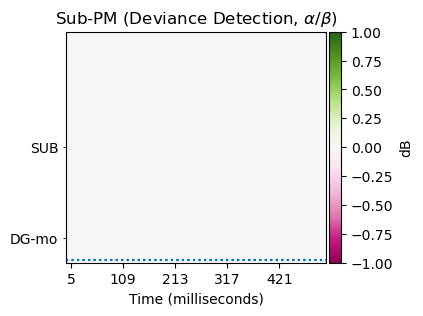

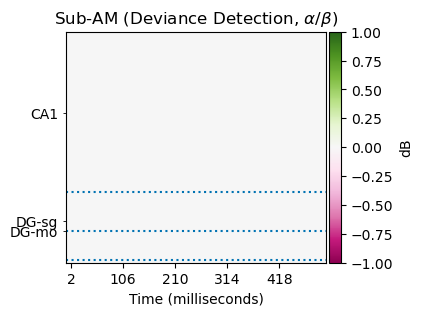

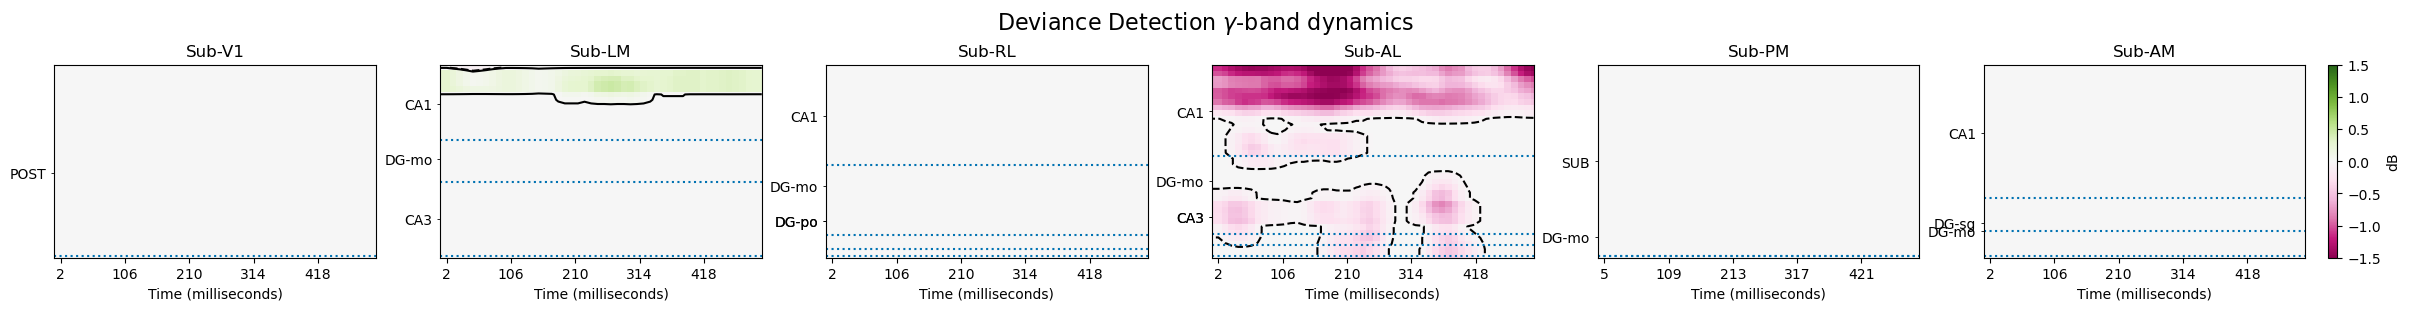

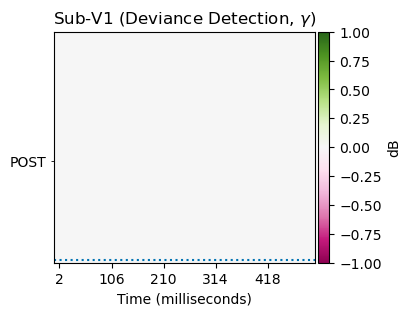

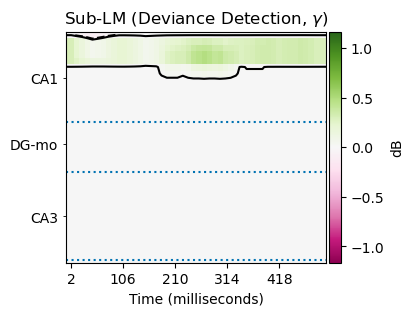

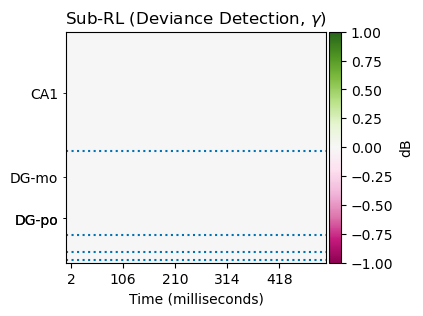

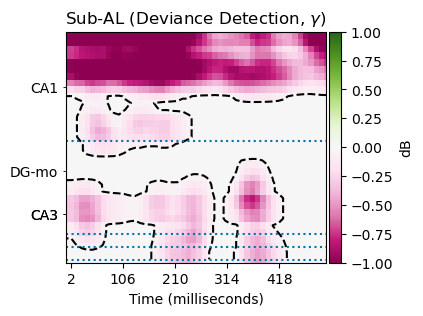

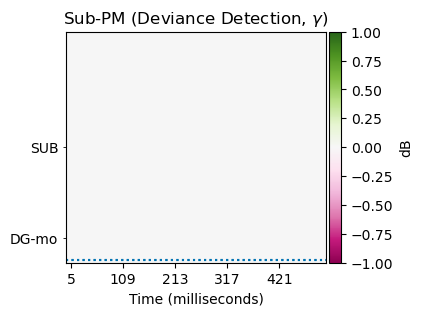

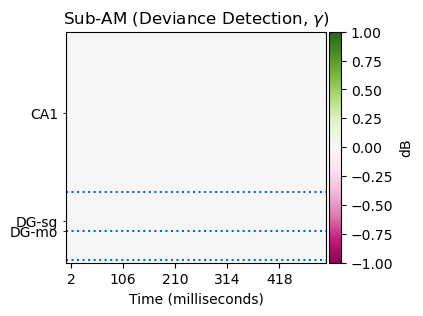

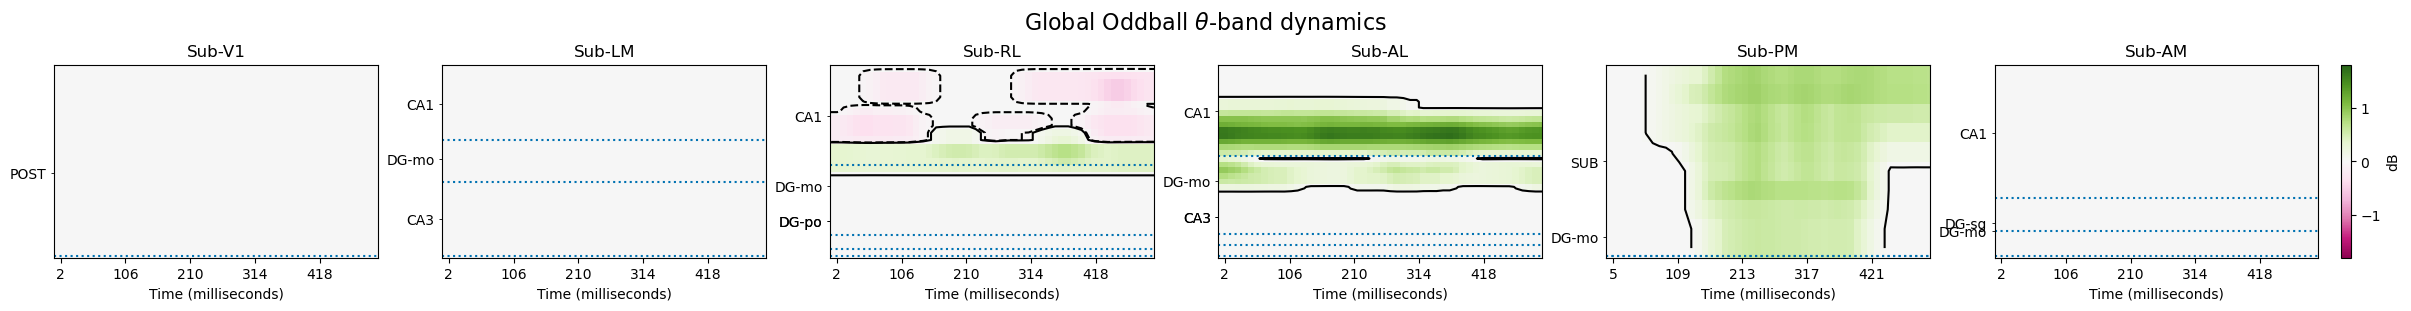

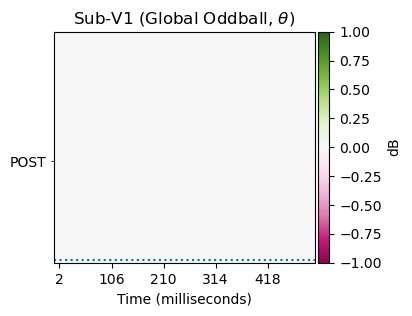

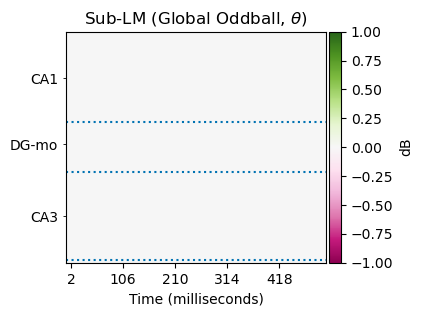

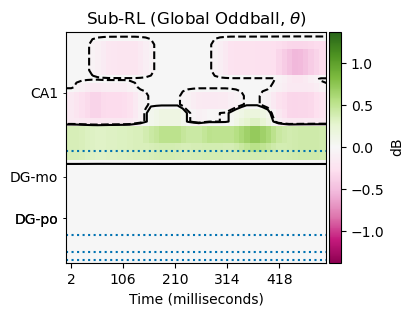

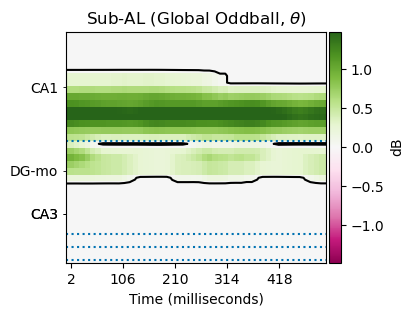

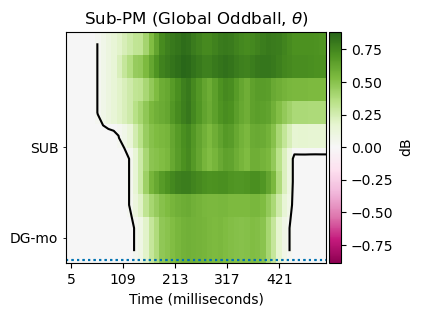

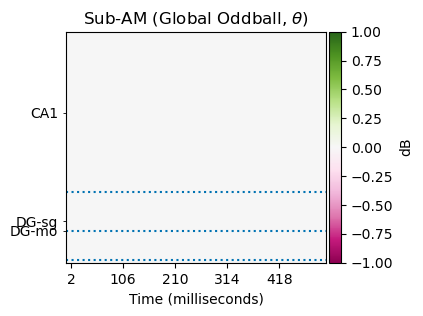

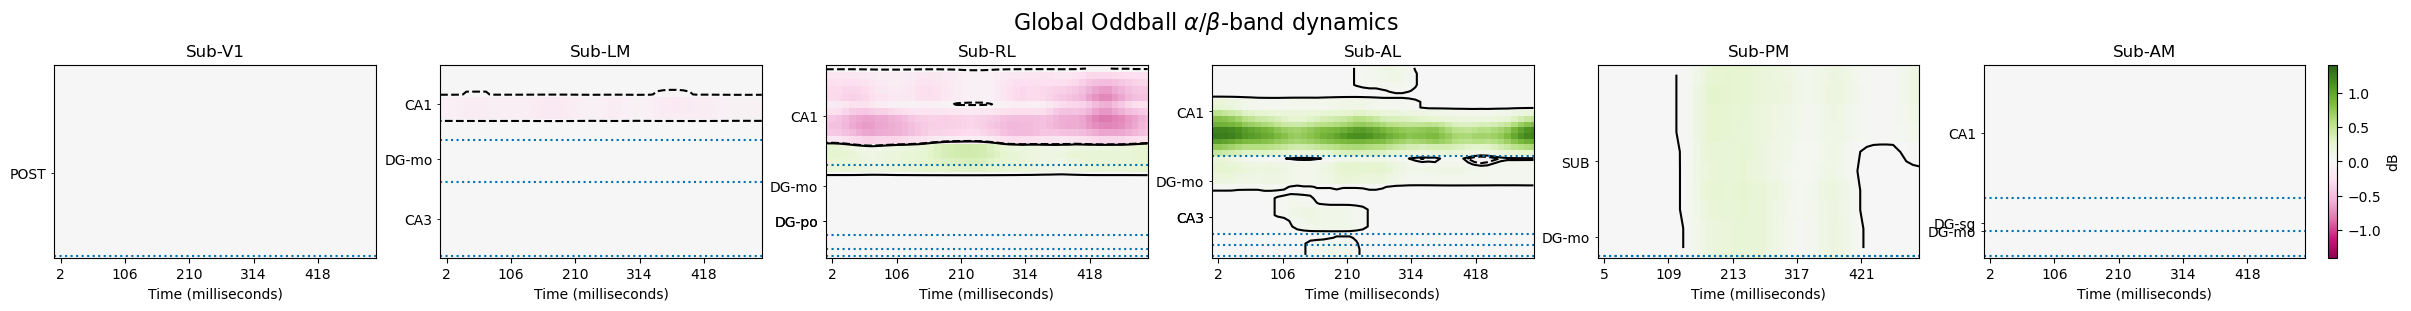

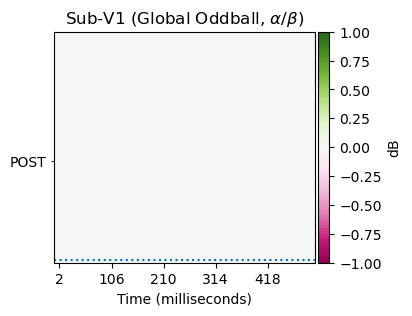

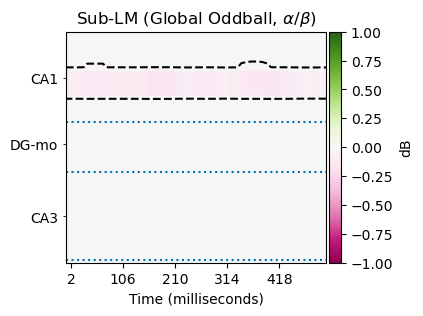

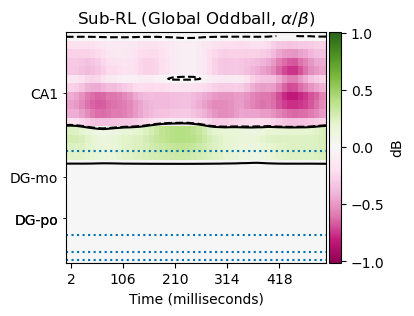

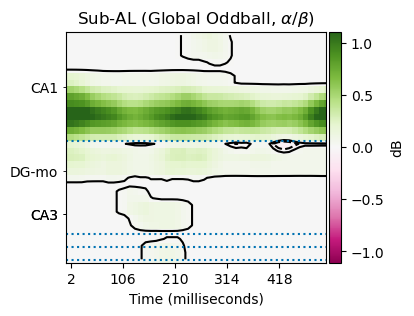

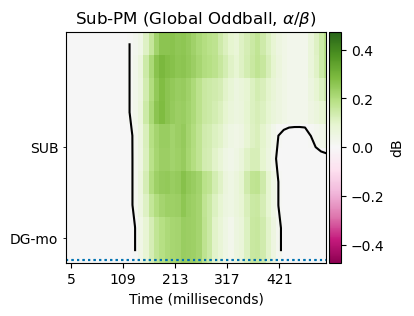

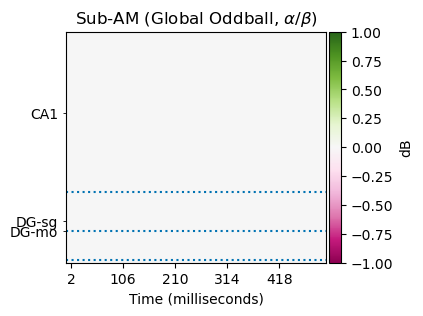

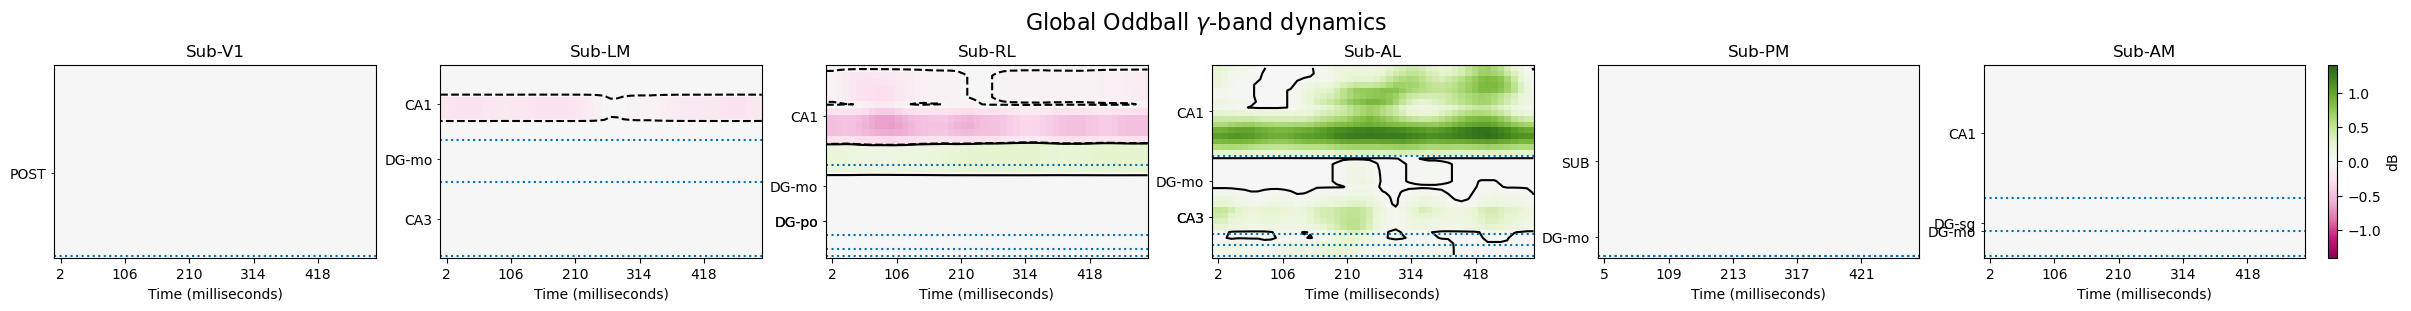

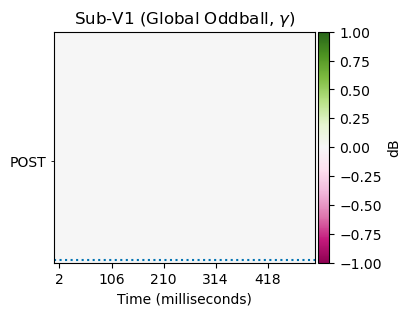

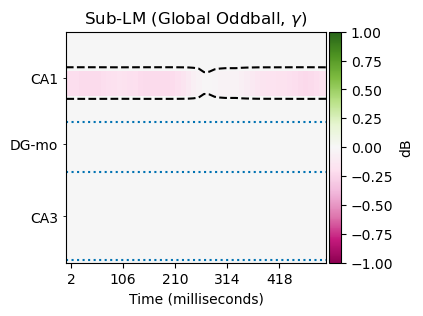

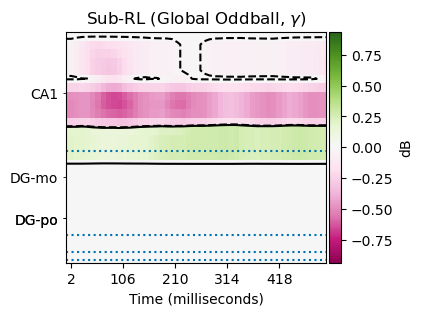

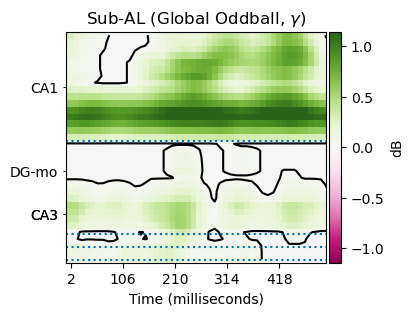

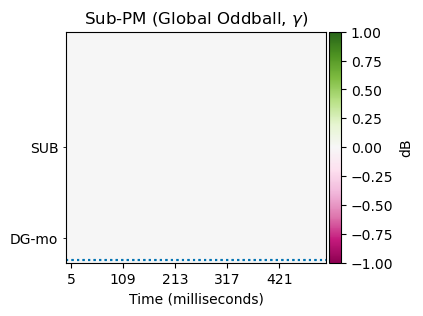

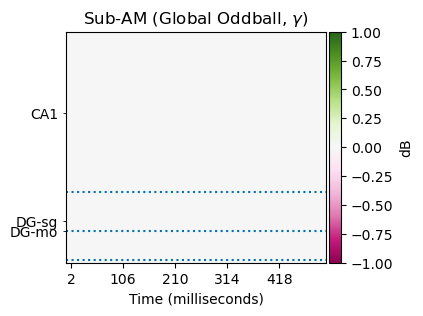

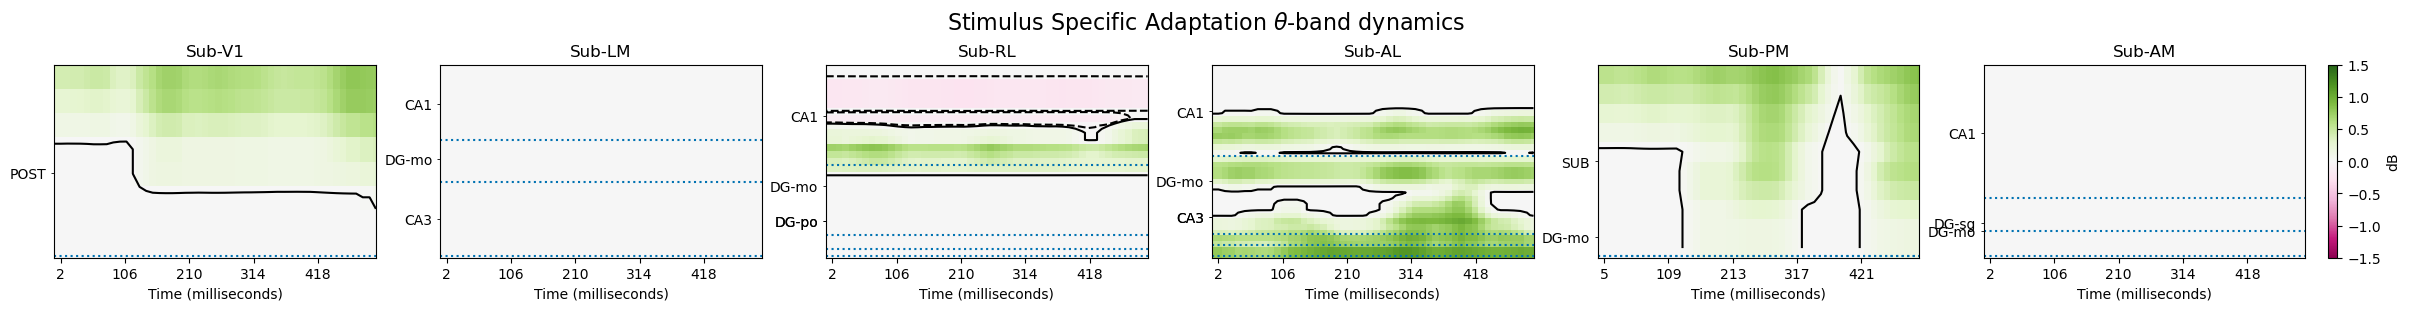

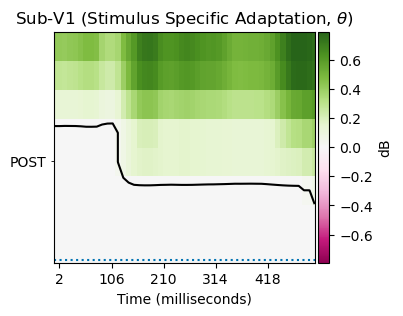

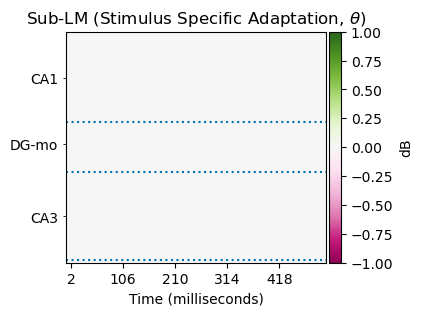

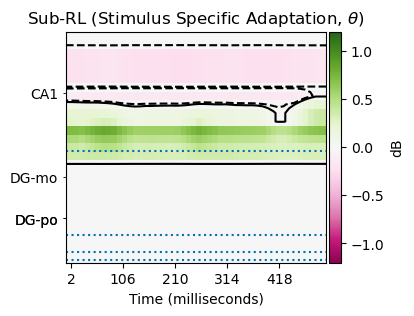

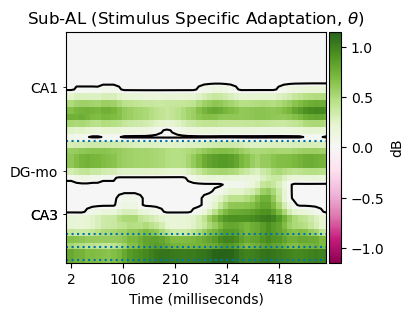

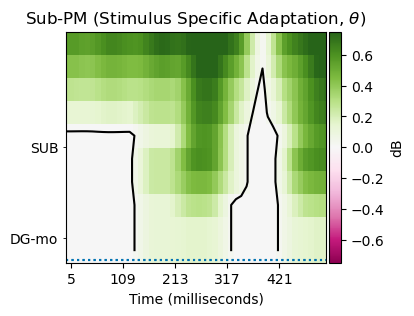

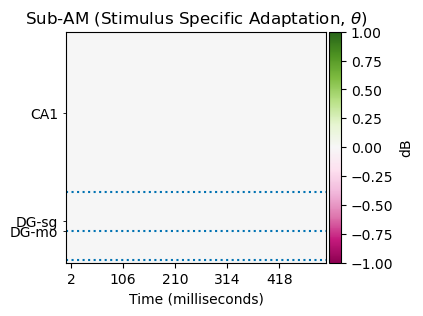

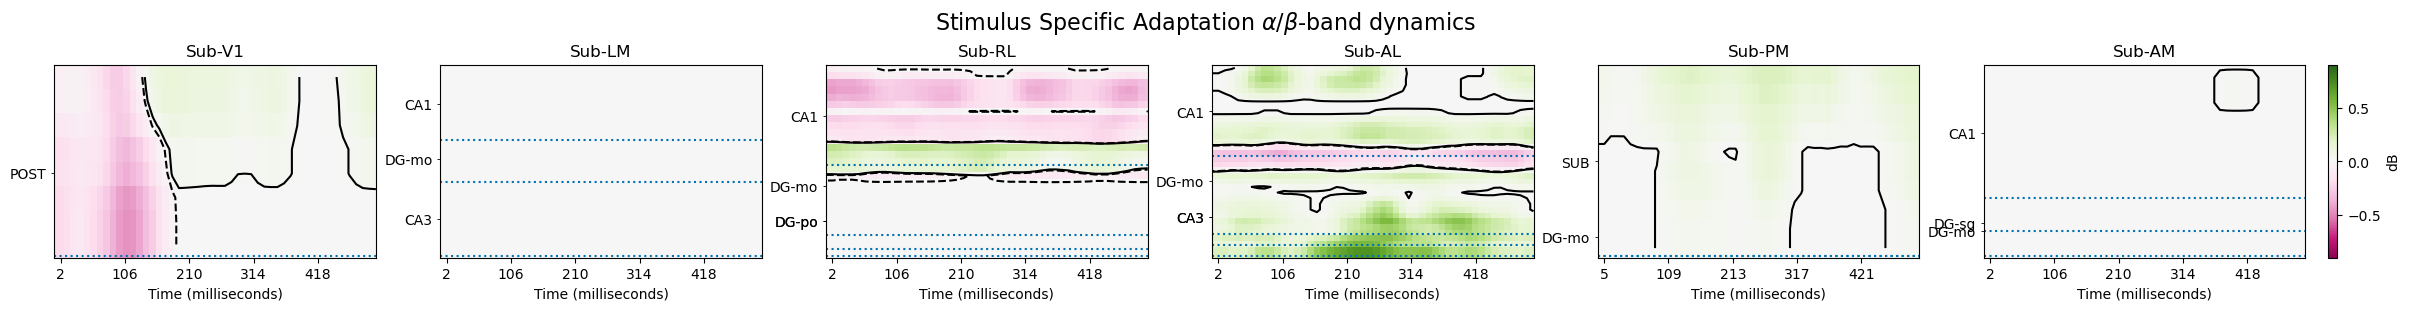

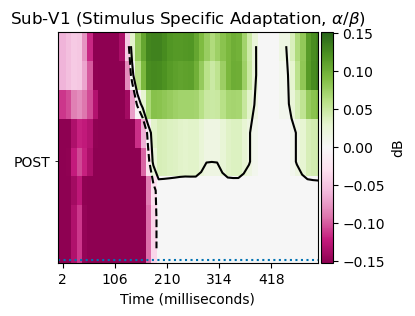

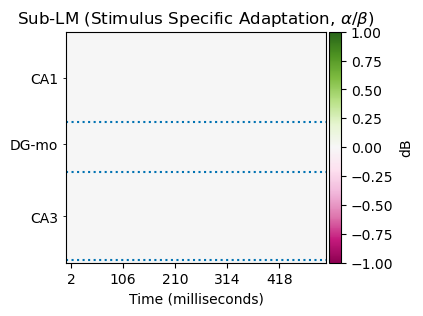

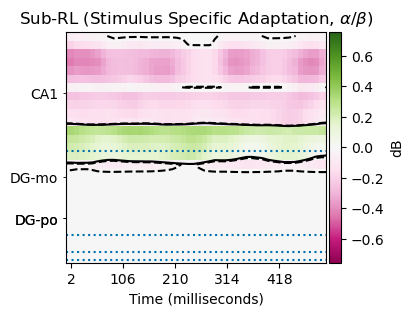

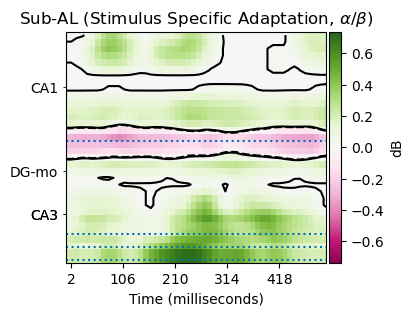

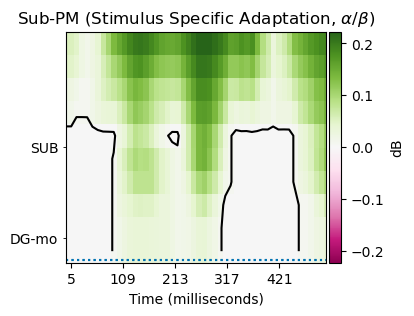

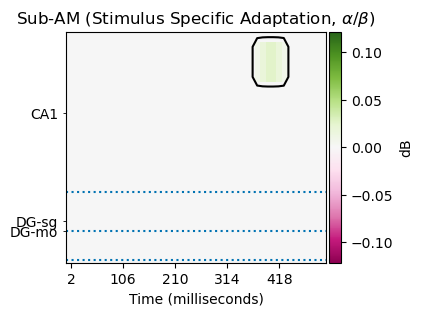

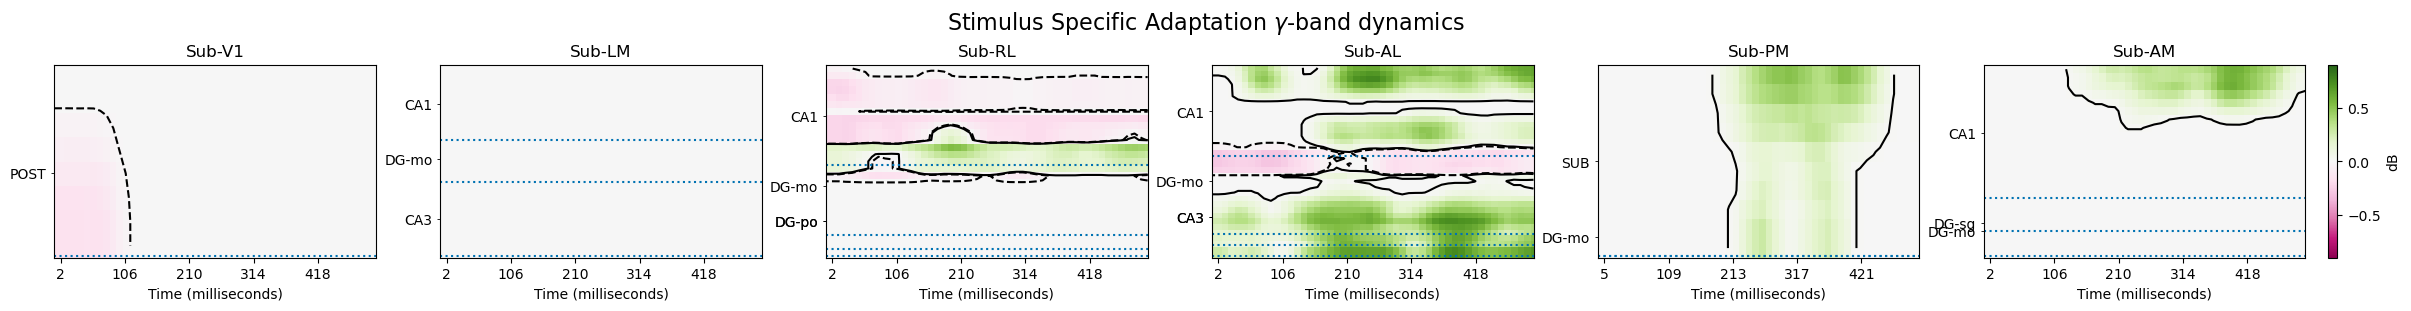

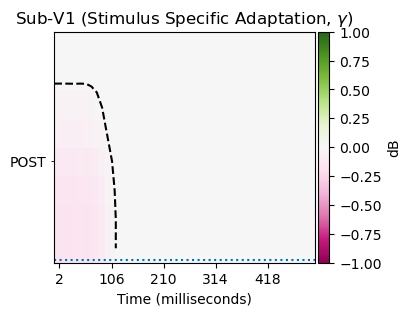

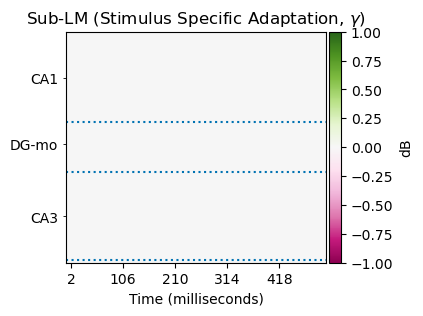

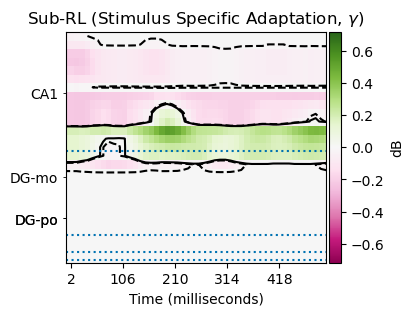

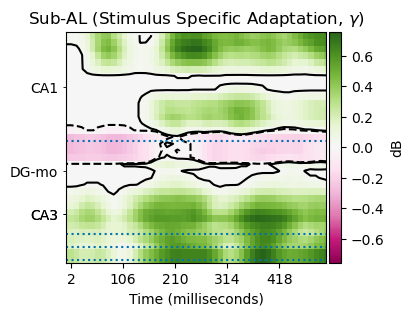

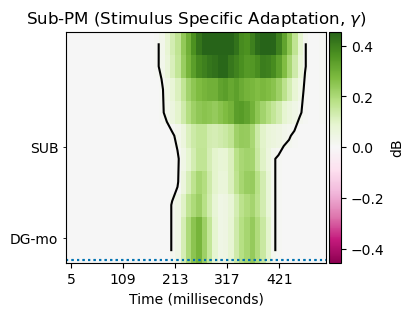

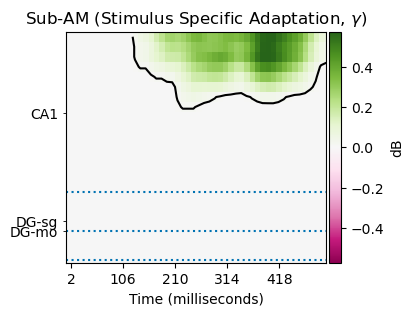

In [32]:
for (name, _, _) in CONTRASTS:
    contrast_title = functools.partial(contrast_stattitle, name)
    contrast = contrasts[name].erp()

    for band, freqs in BANDS.items():
        band_powers = contrast.smap(lambda tfr: tfr.band_power(freqs[0], freqs[1]))
        band_powers.plot(signals=anatomical_areas, sigtitle=stattitle,
                         title="%s %s-band dynamics" % (CONTRAST_TITLES[name], BAND_LATEX[band]), cmap='PiYG', contours=True,
                         figure="oscillatory_hippocampal_%s_%s.svg" % (name, BAND_NAMES[band]))

        for area in anatomical_areas:
            os.makedirs("oscillatory_hippocampal_%s_01/" % name, exist_ok=True)

            band_powers.signals[area].plot(title=contrast_title(area, contrasts[name].signals[area], layer=BAND_LATEX[band]), cmap='PiYG',
                                           filename="oscillatory_hippocampal_%s_01/%s_oddball_%s.svg" % (name, area, BAND_NAMES[band]), contours=True)